✓ Model loaded
Prediction: Polyps
Confidence: 95.67%


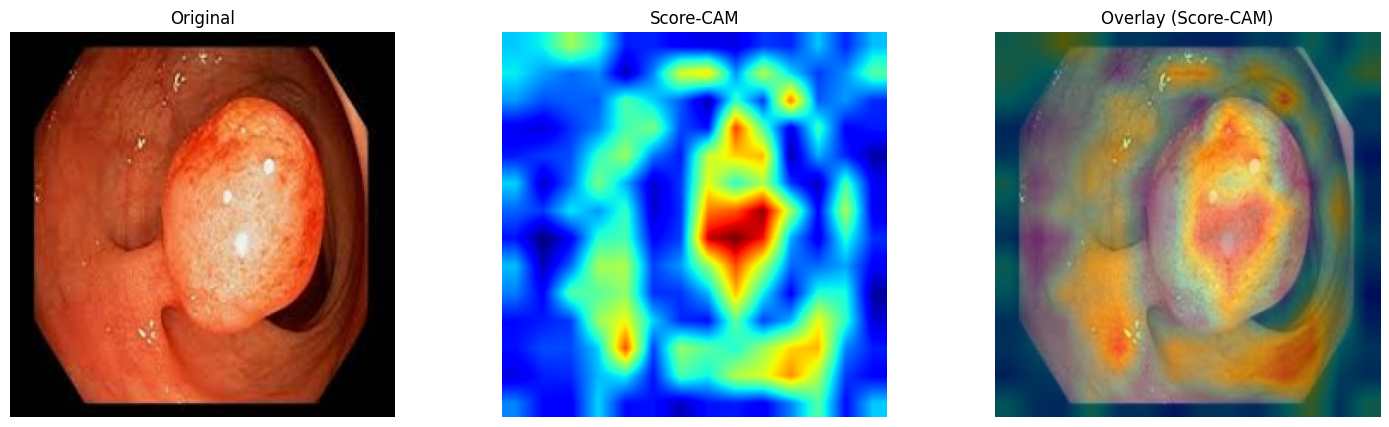

In [2]:


# -------------------- CELL 1: IMPORTS --------------------
import os
import torch
import timm
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
from torchvision import transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224

# -------------------- CELL 2: CLASS NAMES --------------------
CLASS_NAMES = [
    'Normal',
    'Ulcerative Colitis',
    'Polyps',
    'Esophagitis'
]

# -------------------- CELL 3: MODEL DEFINITION --------------------
class EFFResNetViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.eff = timm.create_model('efficientnet_b4', pretrained=False, features_only=True)
        self.res = timm.create_model('resnet50', pretrained=False, features_only=True)

        eff_dim = self.eff.feature_info[-1]['num_chs']
        res_dim = self.res.feature_info[-1]['num_chs']

        self.fusion = nn.Conv2d(eff_dim + res_dim, 768, kernel_size=1)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=768, nhead=12, dim_feedforward=3072,
            dropout=0.2, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.classifier = nn.Sequential(
            nn.LayerNorm(768),
            nn.Dropout(0.4),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        eff = self.eff(x)[-1]
        res = self.res(x)[-1]
        fused = torch.cat([eff, res], dim=1)
        tokens = self.fusion(fused)
        tokens = tokens.flatten(2).transpose(1,2)
        tokens = self.transformer(tokens)
        pooled = tokens.mean(dim=1)
        return self.classifier(pooled)

# -------------------- CELL 4: LOAD TRAINED MODEL --------------------
model = EFFResNetViT(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load('best_effresnetvit.pth', map_location=DEVICE))
model.eval()
print('✓ Model loaded')

# -------------------- CELL 5: IMAGE PREPROCESS --------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)
])

def load_image(path):
    img = Image.open(path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    return img, tensor

# -------------------- CELL 6: SCORE-CAM IMPLEMENTATION --------------------
class ScoreCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        target_layer.register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        self.activations = out.detach()

    def generate(self, x, class_idx, max_maps=32):
        self.model.eval()
        _ = self.model(x)
        maps = self.activations[0]
        maps = torch.relu(maps)

        scores = []
        for i in range(min(max_maps, maps.shape[0])):
            m = maps[i]
            m = (m - m.min()) / (m.max() - m.min() + 1e-8)
            m_up = cv2.resize(m.cpu().numpy(), (IMG_SIZE, IMG_SIZE))
            m_tensor = torch.from_numpy(m_up).float().to(DEVICE)
            masked = x * m_tensor.unsqueeze(0).unsqueeze(0)

            with torch.no_grad():
                score = torch.softmax(self.model(masked), dim=1)[0, class_idx]
            scores.append(score.item() * m_up)

        cam = np.sum(scores, axis=0)
        cam = cam / (cam.max() + 1e-8)
        return cam

# -------------------- CELL 7: OCCLUSION SENSITIVITY --------------------
def occlusion_map(model, x, class_idx, patch=32, stride=16):
    base = torch.softmax(model(x), dim=1)[0, class_idx].item()
    heat = np.zeros((IMG_SIZE, IMG_SIZE))

    for y in range(0, IMG_SIZE, stride):
        for z in range(0, IMG_SIZE, stride):
            occluded = x.clone()
            occluded[:,:,y:y+patch, z:z+patch] = 0
            with torch.no_grad():
                score = torch.softmax(model(occluded), dim=1)[0, class_idx].item()
            heat[y:y+patch, z:z+patch] = base - score

    heat = np.maximum(heat, 0)
    heat = heat / (heat.max() + 1e-8)
    return heat

# -------------------- CELL 8: FULL XAI PIPELINE --------------------
def explain(image_path):
    img, x = load_image(image_path)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        pred = probs.argmax().item()

    print(f'Prediction: {CLASS_NAMES[pred]}')
    print(f'Confidence: {probs[pred]*100:.2f}%')

    # Score-CAM (EfficientNet mid-layer)
    score_cam = ScoreCAM(model, model.eff.blocks[4])
    cam_score = score_cam.generate(x, pred)

    # Occlusion
    cam_occ = occlusion_map(model, x, pred)

    # Visualization
    img_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))

    heat_score = cv2.applyColorMap(np.uint8(255*cam_score), cv2.COLORMAP_JET)
    heat_occ = cv2.applyColorMap(np.uint8(255*cam_occ), cv2.COLORMAP_JET)

    heat_score = cv2.cvtColor(heat_score, cv2.COLOR_BGR2RGB)
    heat_occ = cv2.cvtColor(heat_occ, cv2.COLOR_BGR2RGB)

    overlay_score = np.uint8(0.65*img_np + 0.35*heat_score)
    overlay_occ = np.uint8(0.65*img_np + 0.35*heat_occ)

    plt.figure(figsize=(18,5))
    plt.subplot(1,3,1); plt.imshow(img_np); plt.title('Original'); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(cam_score, cmap='jet'); plt.title('Score-CAM'); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(overlay_score); plt.title('Overlay (Score-CAM)'); plt.axis('off')
    plt.show()

# -------------------- CELL 9: RUN --------------------
# Example:
explain(r"C:\Users\ADMIN\Desktop\images.jpg")



✓ Model loaded
Classes: ['0_normal', '1_ulcerative_colitis', '2_polyps', '3_esophagitis']


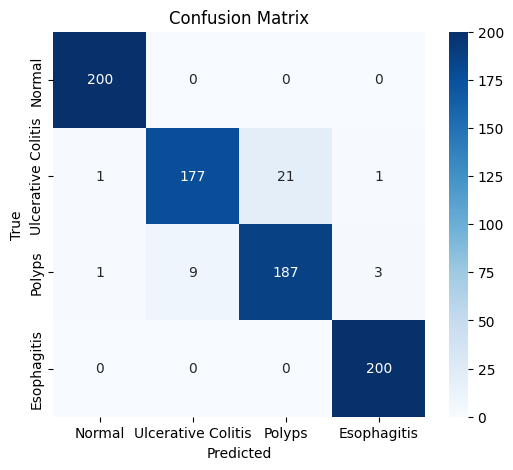

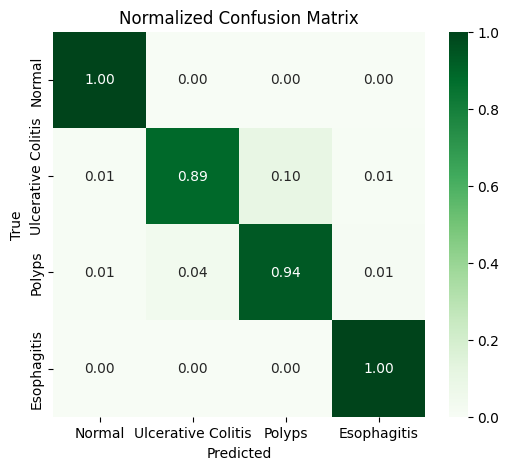


Classification Report (Precision / Recall / F1):

                    precision    recall  f1-score   support

            Normal       0.99      1.00      1.00       200
Ulcerative Colitis       0.95      0.89      0.92       200
            Polyps       0.90      0.94      0.92       200
       Esophagitis       0.98      1.00      0.99       200

          accuracy                           0.95       800
         macro avg       0.96      0.96      0.95       800
      weighted avg       0.96      0.95      0.95       800

Per-class Sensitivity & Specificity:

Normal:
  Sensitivity (Recall): 1.0000
  Specificity:          0.9967

Ulcerative Colitis:
  Sensitivity (Recall): 0.8850
  Specificity:          0.9850

Polyps:
  Sensitivity (Recall): 0.9350
  Specificity:          0.9650

Esophagitis:
  Sensitivity (Recall): 1.0000
  Specificity:          0.9933



In [ ]:

# -------------------- CELL 1: IMPORTS --------------------
import os
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch.nn as nn
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
BATCH_SIZE = 16

# -------------------- CELL 2: CLASS NAMES --------------------
CLASS_NAMES = [
    'Normal',
    'Ulcerative Colitis',
    'Polyps',
    'Esophagitis'
]

# -------------------- CELL 3: MODEL DEFINITION --------------------
class EFFResNetViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.eff = timm.create_model('efficientnet_b4', pretrained=False, features_only=True)
        self.res = timm.create_model('resnet50', pretrained=False, features_only=True)

        eff_dim = self.eff.feature_info[-1]['num_chs']
        res_dim = self.res.feature_info[-1]['num_chs']

        self.fusion = nn.Conv2d(eff_dim + res_dim, 768, kernel_size=1)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=768, nhead=12, dim_feedforward=3072,
            dropout=0.2, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.classifier = nn.Sequential(
            nn.LayerNorm(768),
            nn.Dropout(0.4),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        eff = self.eff(x)[-1]
        res = self.res(x)[-1]
        fused = torch.cat([eff, res], dim=1)
        tokens = self.fusion(fused)
        tokens = tokens.flatten(2).transpose(1,2)
        tokens = self.transformer(tokens)
        pooled = tokens.mean(dim=1)
        return self.classifier(pooled)

# -------------------- CELL 4: LOAD MODEL --------------------
model = EFFResNetViT(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load('best_effresnetvit.pth', map_location=DEVICE))
model.eval()
print('✓ Model loaded')

# -------------------- CELL 5: DATASET --------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)
])

test_dir = r'D:/Project/archive/test'

test_dataset = ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Classes:', test_dataset.classes)

# -------------------- CELL 6: INFERENCE --------------------
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# -------------------- CELL 7: CONFUSION MATRIX --------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Normalized CM
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()

# -------------------- CELL 8: MEDICAL METRICS --------------------
print('\nClassification Report (Precision / Recall / F1):\n')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

print('Per-class Sensitivity & Specificity:\n')

for i, cls in enumerate(CLASS_NAMES):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    sensitivity = TP / (TP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)

    print(f'{cls}:')
    print(f'  Sensitivity (Recall): {sensitivity:.4f}')
    print(f'  Specificity:          {specificity:.4f}\n')
